In [42]:
import corner.corner
import numpy as np
import pandas as pd
import corner
import numpy as np
import pandas as pd
import corner


class MCMCResult:
    """
    Classe che raccoglie e gestisce i risultati di un fitting MCMC.
    L'utente deve passare un 'sampler' (es. emcee.EnsembleSampler),
    oltre a dati, modello, var_names, ecc.
    La catena viene recuperata internamente (senza dover passare chain o flat_samples).

    Changing 'discard' o 'thin' ricalcola automaticamente le statistiche.
    """

    def __init__(
        self,
        sampler,
        model,
        grid,
        data,
        var_names,
        discard=0,
        thin=1,
        # eventuali parametri aggiuntivi
        message="",
        success=True,
        **kwargs,
    ):
        """
        Parametri
        ---------
        sampler : oggetto di tipo emcee.EnsembleSampler (o simile)
            Da cui recuperare i campioni MCMC.
        model : oggetto/funzione
            Utilizzato per calcolare il modello teorico (ad es. model.call).
        grid : array-like
            Griglia (o x) su cui valutare il modello.
        data : array-like
            Dati sperimentali/osservati.
        var_names : list
            Nomi dei parametri variabili nell'ottimizzazione.
        discard : int
            Numero di step iniziali da scartare (burn-in).
        thin : int
            Thinning factor.
        message : str
            Messaggio opzionale sul risultato.
        success : bool
            Flag di successo o meno.
        kwargs : dict
            Altri attributi opzionali da aggiungere all'oggetto.
        """
        self.sampler = sampler
        self.model = model
        self.grid = grid
        self.data = data
        self.var_names = var_names

        # Parametri per gestire burn-in e thinning
        self._discard = discard
        self._thin = thin

        # Altri attributi (es. stato, message, etc.)
        self.success = success
        self.message = message

        # Inizializziamo alcuni attributi che vogliamo calcolare
        self.best_fit = None
        self.residual = None
        self.chisqr = None
        self.redchi = None
        self.aic = None
        self.bic = None
        self.parameter_summary = None

        # Se vogliamo, possiamo salvare ndata e simili:
        self.ndata = len(data) if hasattr(data, "__len__") else 1
        self.nwalkers = (
            self.sampler.nwalkers if hasattr(self.sampler, "nwalkers") else None
        )
        self.nvarys = len(var_names)

        # Qualsiasi altro attributo presente in kwargs
        for k, v in kwargs.items():
            setattr(self, k, v)

        # Calcola subito le statistiche iniziali
        self.calculate_statistics()

    @property
    def discard(self):
        """Numero di step di burn-in scartati."""
        return self._discard

    @discard.setter
    def discard(self, value):
        self._discard = value
        # Ricalcolo le statistiche ogni volta che discard cambia
        self.calculate_statistics()

    @property
    def thin(self):
        """Fattore di thinning."""
        return self._thin

    @thin.setter
    def thin(self, value):
        self._thin = value
        # Ricalcolo le statistiche ogni volta che thin cambia
        self.calculate_statistics()

    @property
    def chain(self):
        """
        Catena MCMC completa (senza flatten), recuperata dal sampler.
        Dimensioni tipiche: (nsteps, nwalkers, n_params)
        Nota: emcee < 3 aveva dimensioni invertite
        """
        # flat=False per ottenere la catena completa
        return self.sampler.get_chain(
            discard=self._discard, thin=self._thin, flat=False
        )

    @property
    def flatchain(self):
        """
        Catena MCMC "flattened" (2D), recuperata dal sampler.
        Dimensioni tipiche: (nsteps * nwalkers, n_params)
        """
        # flat=True per ottenere la catena appiattita
        return self.sampler.get_chain(discard=self._discard, thin=self._thin, flat=True)

    def calculate_statistics(self):
        """
        Ricalcola best-fit (mediana), residui, chisq, redchi, AIC, BIC,
        e percentili (16, 84) usando i campioni in flatchain.
        """
        # Se non ci sono campioni, esci
        flat = self.flatchain
        if flat is None or len(flat) == 0:
            self.best_fit = None
            self.residual = None
            self.chisqr = 0.0
            self.redchi = np.inf
            self.aic = np.inf
            self.bic = np.inf
            self.parameter_summary = {}
            return

        # Calcolo best fit come mediana
        self.best_fit = np.median(flat, axis=0)  # array di dimensione (n_params,)
        self.best_fit_dict = {name:val for name,val in zip(self.var_names, self.best_fit)}
        # Calcolo residui con i parametri best-fit (usando self.model)
        # Assumiamo che la model.call(grid, *params) sia la sintassi
        model_output = self.model.call(self.grid, *self.best_fit)
        # Ravel per sicurezza
        self.residual = (self.data - model_output).ravel()

        # Calcolo chisqr
        self.chisqr = float((self.residual**2).sum())

        # Gradi di libertà e chi-quadro ridotto
        # (eventualmente potremmo salvare un attributo self.nfree = self.ndata - self.nvarys)
        nfree = self.ndata - self.nvarys
        if nfree > 0:
            self.redchi = self.chisqr / nfree
        else:
            self.redchi = np.inf

        # Calcolo AIC e BIC usando chisqr come -2 ln L
        eps = 1e-250
        chisqr_valid = max(self.chisqr, eps * self.ndata)
        _neg2_log_likel = self.ndata * np.log(chisqr_valid / self.ndata)
        self.aic = _neg2_log_likel + 2 * self.nvarys
        if self.ndata > 0:
            self.bic = _neg2_log_likel + np.log(self.ndata) * self.nvarys
        else:
            self.bic = np.inf

        # Calcolo dei percentili 16, 84 e mediana per ciascun parametro
        self.parameter_summary = {}
        for i, pname in enumerate(self.var_names):
            param_samples = flat[:, i]
            p16 = np.percentile(param_samples, 16)
            p84 = np.percentile(param_samples, 84)
            med = np.median(param_samples)
            self.parameter_summary[pname] = {"median": med, "p16": p16, "p84": p84}

    def plot_corner(self):
        """
        Esempio di funzione per generare il corner plot.
        """
        flat = self.flatchain
        if flat is None or len(flat) == 0:
            print("Nessun campione per il corner plot.")
            return
        corner.corner(flat, labels=self.var_names)

    def __repr__(self):
        return (
            f"<MCMCResult success={self.success} chisqr={self.chisqr:.4g} "
            f"redchi={self.redchi:.4g} ndata={self.ndata} nvarys={self.nvarys} "
            f"discard={self.discard} thin={self.thin}>"
        )

    def __str__(self):
        lines = [
            "=== MCMCResult ===",
            f"    success   = {self.success}",
            f"    message   = {self.message}",
            f"    discard   = {self.discard}",
            f"    thin      = {self.thin}",
            f"    ndata     = {self.ndata}",
            f"    nvarys    = {self.nvarys}",
            f"    chisqr    = {self.chisqr:.4g}",
            f"    redchi    = {self.redchi:.4g}",
            f"    aic       = {self.aic:.4g}",
            f"    bic       = {self.bic:.4g}",
        ]
        # Se abbiamo un best_fit
        if self.best_fit is not None:
            lines.append("    best_fit:")
            for pname, val in zip(self.var_names, self.best_fit):
                lines.append(f"        {pname} = {val:.4g}")

        # Se abbiamo summary percentile
        if self.parameter_summary:
            lines.append("\n    Parameter summary (median [p16, p84]):")
            for pname, stats in self.parameter_summary.items():
                lines.append(
                    f"        {pname:15s}: {stats['median']:.4g} "
                    f"[{stats['p16']:.4g}, {stats['p84']:.4g}]"
                )

        return "\n".join(lines)


In [43]:
from typing import Iterable, Union, Dict, Optional
import emcee
import corner


class MCMC:
    """
    Classe wrapper di base per l'utilizzo dell'algoritmo MCMC (Markov Chain Monte Carlo)
    tramite la libreria `emcee`.

    Parameters
    ----------
    model : object
        Istanza di un oggetto modello che deve fornire le seguenti proprietà/metodi:
        - `free_parameters`: lista dei parametri liberi, ciascuno con `.value` e `.bounds` (tuple (min, max)).
        - `call(grid, *theta)`: metodo che, dati un grid e i valori dei parametri, restituisce l'output del modello.
        - `parameters_names`: lista dei nomi di tutti i parametri (sia liberi che non).
        - `parameters_keys`: chiavi identificative di tutti i parametri (sia liberi che non).
        - `parameters_values_dict`: dizionario dei parametri, con nome come chiave e valore come valore del parametro.
        - `n_dim`: dimensione del grid (es. 1D, 2D, ...).
        - `__getitem__(pname)`: per accedere a un parametro a partire dal suo nome (restituisce un oggetto con `.frozen`).

    **kwargs
        Ulteriori argomenti passati internamente a `emcee.EnsembleSampler`. Ad esempio:
        - `moves`
        - `backend`
        - etc.
    """

    def __init__(self, model, **kwargs) -> None:
        self._model = model
        self.emcee_kwargs = (
            kwargs  
        )

    @property
    def model(self):
        """
        Riferimento al modello associato a questa classe MCMC.

        Returns
        -------
        object
            Il modello utilizzato per la stima MCMC.
        """
        return self._model

    def logprior(self, theta: np.ndarray) -> float:
        """
        Calcola il log-prior per i parametri `theta`.

        Il prior è zero se tutti i parametri rientrano nei rispettivi bounds,
        altrimenti ritorna `-np.inf`.

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.

        Returns
        -------
        float
            Il valore della log-prior.
        """
        return max(param(val) for param, val in zip(self.model.free_parameters, theta))
        #return max(param)
        # Controlla se ogni parametro è all'interno dei suoi bounds
        #for param, val in zip(self.model.free_parameters, theta):
            
            #if val < param.bounds[0] or val > param.bounds[1]:
        #        return -np.inf
        #return 0.0

    def loglike(
        self,
        theta: np.ndarray,
        xdata: Union[list, np.ndarray],
        ydata: Union[list, np.ndarray],
        yerr: Union[list, np.ndarray],
    ) -> float:
        """
        Calcola la log-likelihood dati i dati e il modello,
        assumendo errori gaussiani indipendenti.

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.
        xdata : array-like
            Dati indipendenti (es. valori di ascissa).
        ydata : array-like
            Dati osservati (es. valori di ordinata).
        yerr : array-like
            Incertezze (errore standard) associate ai dati osservati.

        Returns
        -------
        float
            Valore della log-likelihood.
        """
        # Calcolo del modello
        ymodel = self.model.call([xdata], *theta)
        # Residui e calcolo della likelihood
        residuals = ydata - ymodel
        ln = -0.5 * np.sum((residuals**2 / yerr**2) + np.log(2 * np.pi * yerr**2))
        return ln

    def log_probability(
        self,
        theta: np.ndarray,
        xdata: Union[list, np.ndarray],
        ydata: Union[list, np.ndarray],
        yerr: Union[list, np.ndarray],
    ) -> float:
        """
        Calcola la log-probability (somma di log-prior e log-likelihood).

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.
        xdata : array-like
            Dati indipendenti.
        ydata : array-like
            Dati osservati.
        yerr : array-like
            Incertezze (errore standard) associate ai dati osservati.

        Returns
        -------
        float
            Valore della log-probabilità (log-prior + log-likelihood).
        """
        lp = self.logprior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + self.loglike(theta, xdata, ydata, yerr)

    def _emcee_positions(
        self, theta0: np.ndarray, nwalkers: int, bounds: list, dispersion:float,
    ) -> np.ndarray:
        """
        Genera una matrice di posizioni iniziali per emcee con dispersione
        del 10% rispetto ai parametri iniziali. I punti fuori dai bound
        specificati vengono rigenerati.

        Parameters
        ----------
        theta0 : np.ndarray
            Posizione iniziale dei parametri, array di forma (ndim,).
        nwalkers : int
            Numero di walkers per emcee.
        bounds : list of tuple
            Lista di tuple (lower_bound, upper_bound) per ciascun parametro.

        Returns
        -------
        np.ndarray
            Array di forma (nwalkers, ndim) contenente le posizioni iniziali
            dei walkers.
        """
        ndim = len(theta0)
        pos = np.zeros((nwalkers, ndim))
        
        if dispersion < 0 or dispersion > 1:
            raise ValueError("Initial points dispersion must be > 0 and < 1")

        # Controllo che l'inizializzazione non sia fuori dai bound
        for i, point in enumerate(theta0):
            if not (bounds[i][0] < point < bounds[i][1]):
                raise ValueError(
                    f"Il valore iniziale per il parametro '{self.model.parameters_names[i]}' "
                    f"è fuori dal bound {bounds[i]}!"
                )

        def generate_valid_position() -> np.ndarray:
            while True:
                # Genera una posizione con dispersione casuale (10%)
                candidate = theta0 + dispersion * np.abs(theta0) * (
                    2 * np.random.rand(ndim) - 1
                )
                # Controlla se tutti i parametri rispettano i bound
                if all(
                    lower <= value <= upper
                    for value, (lower, upper) in zip(candidate, bounds)
                ):
                    return candidate

        # Popola l'array con posizioni valide per ciascun walker
        for i in range(nwalkers):
            pos[i] = generate_valid_position()

        return pos

    def _check_initial_state(
        self,
        theta0: Optional[Union[list, np.ndarray, Dict[str, float]]],
        grid: Union[list, np.ndarray],
        data: Union[list, np.ndarray],
    ) -> np.ndarray:
        """
        Verifica e prepara lo stato iniziale `theta0` in base a come viene fornito (lista, array, dict).
        Inoltre controlla la compatibilità tra dimensione dei dati e output del modello.

        Parameters
        ----------
        theta0 : list or np.ndarray or dict, optional
            Stima iniziale dei parametri. Se `None`, vengono usati i valori
            già presenti nel modello per i parametri liberi.
        grid : array-like
            Grid su cui valutare il modello (può essere monodimensionale o multidimensionale).
        data : array-like
            Valori osservati corrispondenti alla valutazione del modello su `grid`.

        Returns
        -------
        np.ndarray
            Array di valori iniziali (stima dei parametri) in formato numpy (ndim,).

        Raises
        ------
        TypeError
            Se `grid` non è un array-like o se `theta0` non è un tipo supportato (list, dict, np.ndarray).
        ValueError
            Se la dimensione del `grid` non corrisponde a quella attesa dal modello,
            o se la lunghezza di `theta0` non corrisponde al numero di parametri liberi,
            o se la dimensione dei dati non corrisponde alla dimensione dell'output del modello.
        """
        if not isinstance(grid, (list, np.ndarray)):
            raise TypeError(
                "`grid` deve essere una lista o un numpy array (es. [X], [X, Y, ...])."
            )
        if isinstance(grid, list):
            grid = np.array(grid)

        # Controllo dimensione `grid` e modello
        if np.shape(grid)[0] != self.model.n_dim:
            raise ValueError(
                f"La dimensione del grid ({grid.ndim}) non corrisponde "
                f"alla dimensione del modello ({self.model.n_dim})."
            )

        # Se theta0 è None, uso i valori del modello
        if theta0 is None:
            theta0 = [p.value for p in self.model.free_parameters]

        # Se theta0 è un dict
        if isinstance(theta0, dict):
            # Copio i parametri correnti del modello
            initial = {**self.model.parameters_values_dict}
            for pname, pval in theta0.items():
                param = self.model[pname]
                if param.frozen:
                    raise ValueError(
                        f"Il parametro '{pname}' è frozen. Fornire solo valori per parametri free."
                    )
                initial[pname] = pval
            # Ricostruisco array in ordine
            theta0 = np.array(
                [
                    initial[name]
                    for name in self.model.parameters_keys
                    if not self.model[name].frozen
                ]
            )
        elif isinstance(theta0, (list, np.ndarray)):
            theta0 = np.array(theta0, dtype=float)
        else:
            raise TypeError(
                "L'ipotesi iniziale (theta0) deve essere una lista, un dict o un numpy array."
            )

        # Verifico che sia veramente un np.ndarray
        assert isinstance(theta0, np.ndarray)

        # Check lunghezza theta0 = numero di parametri liberi
        if len(theta0) != len(self.model.free_parameters):
            raise ValueError(
                f"Il numero di valori iniziali ({len(theta0)}) non corrisponde "
                f"al numero di parametri liberi ({len(self.model.free_parameters)})."
            )

        # Verifica della compatibilità tra dati e output del modello
        model_output = self.model.call(grid, *theta0)
        if np.shape(model_output) != np.shape(data):
            raise ValueError(
                f"La dimensione dei dati {np.shape(data)} non corrisponde "
                f"alla dimensione dell'output del modello {np.shape(model_output)}."
            )

        return theta0, grid

    def fit(
        self,
        #grid: Union[list, np.ndarray],
        data: Union[list, np.ndarray],
        theta0: Optional[Union[list, np.ndarray, Dict[str, float]]] = None,
        error: Optional[Union[list, np.ndarray]] = None,
        nwalkers: int = 32,
        nsteps: int = 5000,
        discard: int = 100,
        #thin: int = 15,
        dispersion:float|int = 0.1,
        optimize:bool = False,
        **kwargs,
    ):
        # TODO modificare dispersion e initial pointin modo da permettere di avere come input direttamente l'array corretto come emcee
        """
        Esegue il fitting MCMC del modello sui dati forniti.

        Parameters
        ----------
        grid : array-like
            Grid (indipendente) su cui valutare il modello (es. asse x).
        data : array-like
            Dati osservati corrispondenti alla valutazione del modello su `grid`.
        theta0 : list or np.ndarray or dict, optional
            Stima iniziale dei parametri. Se `None`, vengono usati i valori
            già presenti nel modello per i parametri liberi.
        error : array-like, optional
            Incertezze (errore standard) sui dati osservati.
            Se `None`, si assume un errore costante (o lo si può gestire diversamente).
        nwalkers : int, optional
            Numero di walker da utilizzare nell'algoritmo MCMC (default=32).
        nsteps : int, optional
            Numero di passi da eseguire per ogni walker (default=5000).
        discard : int, optional
            Numero di step iniziali (burn-in) da scartare (default=100).
        thin : int, optional
            Frequenza di thinning; un valore di 15 significa prendere 1 campione ogni 15 (default=15).
        **kwargs : dict
            model.grid_variables possono essere passate direttammente.\
            Argomenti aggiuntivi passati a `emcee.EnsembleSampler.run_mcmc`.

        Returns
        -------
        flat_samples : np.ndarray
            Array di campioni estratti dalla catena MCMC dopo il burn-in e il thinning.
        fig : matplotlib.figure.Figure
            Figura `corner` che mostra le distribuzioni a posteriori dei parametri.
        """
        # check sulla griglia data come kwargs
        grid = []
        for var in self.model.grid_variables:
            if var in kwargs:
                element = kwargs.pop(var)
                grid.append(element)
            else:
                raise KeyError(f"La variabile '{var}' non è presente in kwargs.")
            
        
        self.emcee_kwargs.update(**kwargs)
        # Controlla lo stato iniziale e i dati
        theta0, grid = self._check_initial_state(theta0=theta0, grid=grid, data=data)
        
        if optimize is True:
            # guess initial position by optimization
            from scipy.optimize import minimize
            initial_point = minimize(
                self.log_probability,
                x0=theta0,
                args=(grid, data, error),
                bounds=[p.bounds for p in self.model if not p.frozen],
                
            )
            if initial_point.success:
                print(f"Optimization done, initial position is {initial_point.x}")
                theta0 = initial_point.x
            #raise NotImplementedError('Prior Optimization not implemented yet')

        # Genera posizioni iniziali per i walker
        init_positions = self._emcee_positions(
            dispersion = dispersion,
            theta0=theta0,
            nwalkers=nwalkers,
            bounds=[p.bounds for p in self.model if not p.frozen],
        )

        nwalkers, ndim = init_positions.shape

        # Inizializza il sampler di emcee
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            self.log_probability,
            args=(grid, data, error),
            **self.emcee_kwargs,
        )

        #setattr( sampler, "log_prob_fn",lambda p: self.log_probability(p, grid, data, error))
        # Esecuzione MCMC vera e propria
        sampler.run_mcmc(init_positions, nsteps, progress=True, **kwargs)

        # Estrae i campioni (flattening delle catene dopo burn-in e thinning)
        # Ottieni la catena completa (senza scartare e senza thinning)
        #chain = sampler.get_chain(discard=discard, thin=1, flat=False)
        # Ottieni i campioni "flattened" dopo burn-in e thinning
        #flat_samples = sampler.get_chain(discard=discard, thin=thin, flat=True)

        # Stima dei parametri "best fit" (qui usiamo la mediana come esempio)
        #best_fit = np.median(flat_samples, axis=0)

        # Calcolo dei residui con i parametri best fit
        #model_output = self.model.call(grid, *best_fit)
        # Ravel se i dati sono multidimensionali
        #residual = (data - model_output).ravel()

        # Prepara i nomi dei parametri
        labels = [key for key in self.model.parameters_keys if not self.model[key].frozen]

        # Costruiamo un dizionario dei parametri best-fit
        #best_params = dict(zip(labels, best_fit))

        # Creiamo la figura corner (opzionale, la conserviamo come attributo)
        #fig = corner.corner(flat_samples, labels=labels)

        # Inizializziamo MCMCResult
        # 2) Crea l'oggetto MCMCResult passandogli il sampler e gli altri oggetti necessari
        result = MCMCResult(
            sampler=sampler,
            model=self.model,  # ad esempio un oggetto con metodo .call
            grid=grid,
            data=data,
            var_names=labels,     # lista dei nomi
            discard=discard,           # burn-in
            thin=1,              # thinning
            success=True,
            message="MCMC sampling completed successfully"
        )

        # (Facoltativo) Se preferisci, puoi assegnare la figura dopo la creazione
        # result.corner_plot = fig

        return result


In [44]:
from model import Model
import matplotlib.pyplot as plt

def line(x,a,b):
    return a*x + b

line_model = Model.wrap(line, grid_variables=["x"])
print(line_model)

MODEL NAME: SimpleModel
FREE PARAMS: 2
GRID VARIABLES: ['x']
N-DIM: 1
----------------------------------------------------------------------------------------------------
  INDEX  NAME      VALUE  FROZEN    PRIOR               DESCR
      0  a             1  No        Uniform(-inf, inf)
      1  b             1  No        Uniform(-inf, inf)


Text(0, 0.5, 'y')

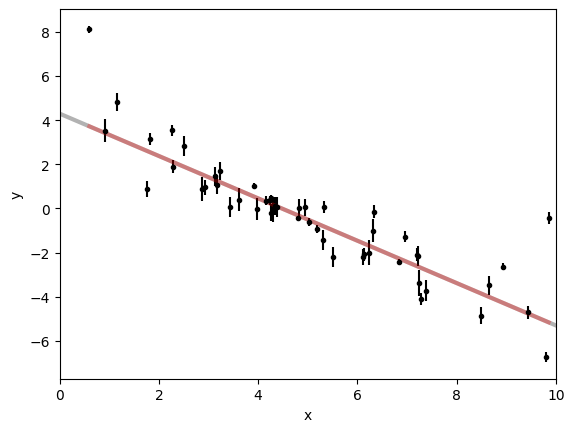

In [45]:


np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = line(x, m_true,b_true)
y_model = line_model(x, a=m_true, b=b_true)

y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.plot(x, y_model, "r", alpha=0.3, lw=3)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

In [46]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    #model = line_model.call([x], *theta[:-1])
    #log_f = theta[-1]
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [47]:
pos = np.array([-1.003,4.528,0.454]) + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape


sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
sampler.run_mcmc(pos, 5000, progress=True)


100%|██████████| 5000/5000 [00:05<00:00, 998.72it/s] 


State([[-0.97510039  4.36782527 -0.81605491]
 [-1.00601678  4.53260885 -0.83056728]
 [-0.93720894  4.17938317 -0.59033622]
 [-0.97531722  4.33909642 -0.94403177]
 [-1.02843595  4.58418601 -0.7425016 ]
 [-0.98223728  4.46479341 -0.92021177]
 [-1.04021281  4.67999111 -0.61881   ]
 [-1.09903011  4.99589969 -1.01713356]
 [-0.98506927  4.35514345 -0.83218987]
 [-1.08410398  4.9536327  -0.80589734]
 [-0.89350028  4.0577179  -0.83305118]
 [-0.90012021  4.17058709 -0.53366821]
 [-0.94096627  4.1869666  -0.99341455]
 [-0.96997551  4.39642426 -0.77344701]
 [-1.17169827  5.23268465 -0.90377596]
 [-0.95282045  4.3255526  -0.62270333]
 [-0.99906624  4.53237367 -0.7575723 ]
 [-0.96521987  4.38259859 -0.77109266]
 [-1.11843496  4.99351218 -0.91155153]
 [-1.19332932  5.37875954 -0.81625816]
 [-1.05994494  4.77775148 -0.71913327]
 [-1.01817051  4.60896984 -0.51209248]
 [-1.03159293  4.67263191 -0.70591701]
 [-1.0835509   4.90955135 -0.78323465]
 [-0.87782327  3.97027209 -0.29518059]
 [-0.96783639  4.35

(10432, 3)


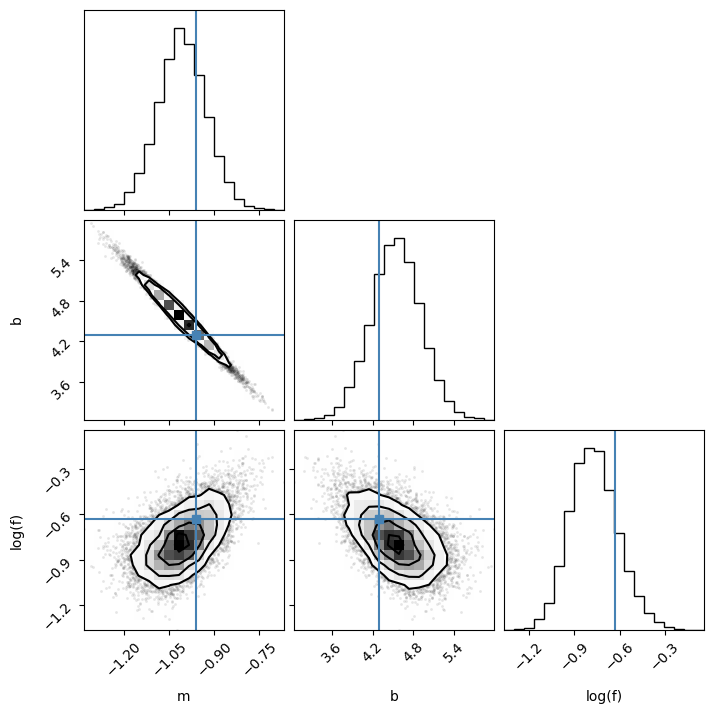

In [48]:
import corner
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)
labels = ["m", "b", "log(f)"]

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)


In [49]:
wrapper = MCMC(line_model)

result = wrapper.fit(#grid = np.array([x]),
            x = x,
            data = y,
            error = yerr,
            theta0 = None,
            nwalkers=32
            #ndim=2
            )

100%|██████████| 5000/5000 [00:07<00:00, 657.14it/s]


In [50]:
print(result)

=== MCMCResult ===
    success   = True
    message   = MCMC sampling completed successfully
    discard   = 100
    thin      = 1
    ndata     = 50
    nvarys    = 2
    chisqr    = 77.61
    redchi    = 1.617
    aic       = 25.98
    bic       = 29.81
    best_fit:
        a = -1.104
        b = 5.439

    Parameter summary (median [p16, p84]):
        a              : -1.104 [-1.12, -1.088]
        b              : 5.439 [5.35, 5.528]


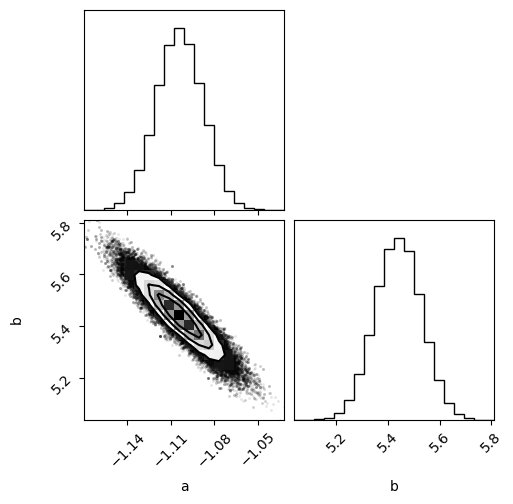

In [51]:


fig = corner.corner(result.flatchain, labels = result.var_names)

Text(0, 0.5, 'y')

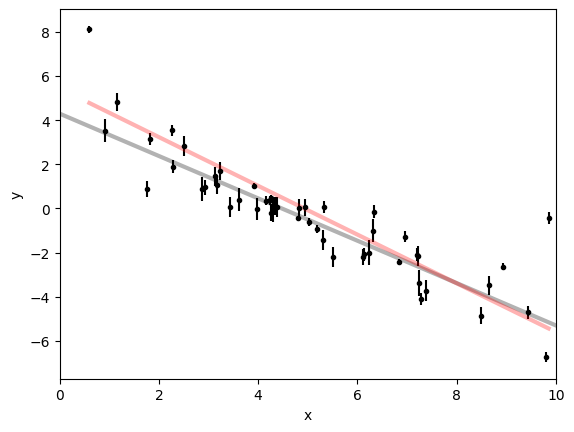

In [52]:

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.plot(x, line_model(x, **result.best_fit_dict), "r", alpha=0.3, lw=3)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")


In [53]:
import numpy as np
from model import Model

def line(x, a, b):
    return a * x + b

def gaussian(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))

gaus = Model.wrap(gaussian, grid_variables=['x'], name = 'Gaussian')

line1 = Model.wrap(line, grid_variables=['x'], name='line')

cmodel = (gaus + gaus) + line1

cmodel.set_parameters_values(
    mu_0 =5.2,
    sigma_1 = 1.2,
    A_1 = 10,
    a_2 = 1.2,
    sigma_0 = .3,
    A_0 = 13.4,
    mu_1 = 2.5,
    b_2 = 0.01
)

print(cmodel)
cmodel.print_tree()

COMPOSITE MODEL NAME: CompositeModel
CONTAINED MODELS: Gaussian, Gaussian, line
GRID VARIABLES: ['x']
LOGIC: ((Gaussian [0] + Gaussian [1]) + line [2])
FREE PARAMS: 8
------------------------------------------------------------
  INDEX  NAME       VALUE  FROZEN    PRIOR               DESCR
      0  mu_0        2.5   No        Uniform(-inf, inf)
      1  sigma_0     0.3   No        Uniform(-inf, inf)
      2  A_0        13.4   No        Uniform(-inf, inf)
      3  mu_1        2.5   No        Uniform(-inf, inf)
      4  sigma_1     0.3   No        Uniform(-inf, inf)
      5  A_1        13.4   No        Uniform(-inf, inf)
      6  a_2         1.2   No        Uniform(-inf, inf)
      7  b_2         0.01  No        Uniform(-inf, inf)
Composite(op='+')
    |-- Composite(op='+')
    |   |-- Gaussian
    |   `-- Gaussian
    `-- line


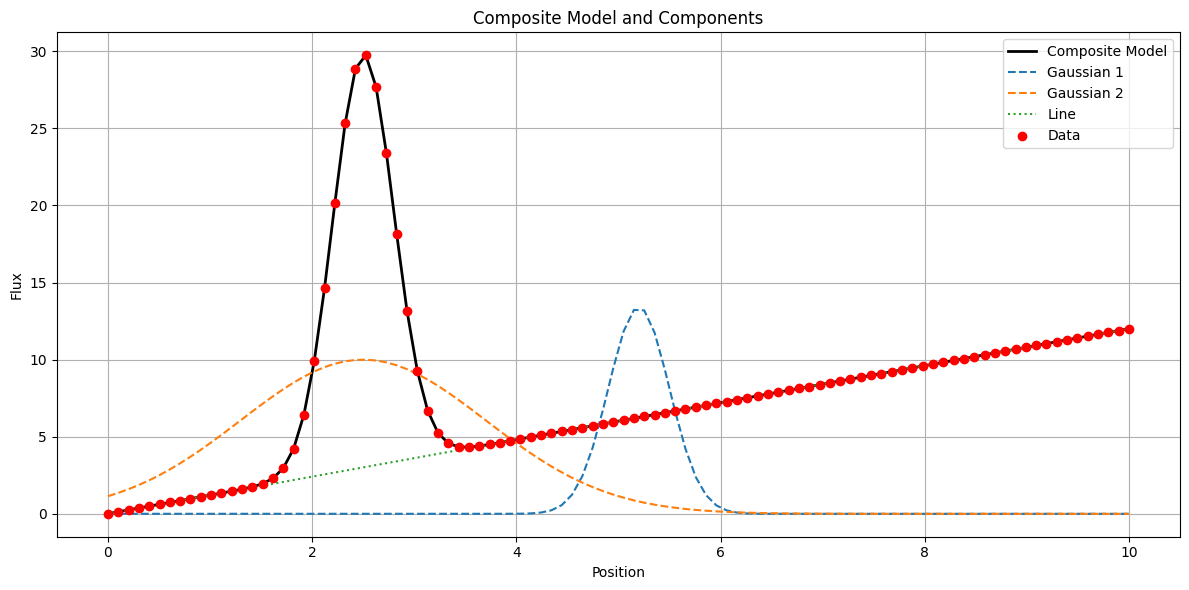

In [54]:
import matplotlib.pyplot as plt
# Define the x range
X = np.linspace(0, 10, 100)

# Evaluate the composite model and its components
y = cmodel.call([X], *cmodel.parameters_values)

gaus_0 = gaus.copy()
gaus_0.set_parameters_values(mu=5.2, sigma=0.3, A=13.4)
gaus_1 = gaus.copy()
gaus_1.set_parameters_values(mu=2.5, sigma=1.2, A=10)
line1.set_parameters_values(a=1.2, b=0.01)

y_gaus_0 = gaus_0.call([X], *gaus_0.parameters_values)
y_gaus_1 = gaus_1.call([X], *gaus_1.parameters_values)
y_line1 = line1.call([X], *line1.parameters_values)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(X, y, "k-", label="Composite Model", linewidth=2)
plt.plot(X, y_gaus_0, "--", label="Gaussian 1", linewidth=1.5)
plt.plot(X, y_gaus_1, "--", label="Gaussian 2", linewidth=1.5)
plt.plot(X, y_line1, ":", label="Line", linewidth=1.5)
plt.scatter(X, y, color="red", label="Data", zorder=5)

plt.title("Composite Model and Components")
plt.xlabel("Position")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [55]:
#cmodel.freeze_parameters('A_0')
opt = MCMC(cmodel)

result = opt.fit(#grid = np.array([X]),  #TODO far funzionare con semplicemente X, controllare dimensione modello
                 x = X,
                 data = y,
                 error = y/100,
                 #theta0={'mu_0':2, "A_0":1},
                 discard = 100,
                 dispersion=0.02,
                 nsteps=1000,
                 optimize=True
                 )

/tmp/ipykernel_290661/3893588114.py:105: RuntimeWarning: overflow encountered in divide
  ln = -0.5 * np.sum((residuals**2 / yerr**2) + np.log(2 * np.pi * yerr**2))
/home/matteo/.pyenv/versions/3.11.6/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/matteo/.pyenv/versions/3.11.6/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
100%|██████████| 1000/1000 [00:03<00:00, 281.19it/s]


In [56]:
print(result)
#print(cmodel)


=== MCMCResult ===
    success   = True
    message   = MCMC sampling completed successfully
    discard   = 100
    thin      = 1
    ndata     = 100
    nvarys    = 8
    chisqr    = 0.04693
    redchi    = 0.0005101
    aic       = -750.4
    bic       = -729.6
    best_fit:
        mu_0 = 2.504
        sigma_0 = 0.2987
        A_0 = 14.04
        mu_1 = 2.497
        sigma_1 = 0.2986
        A_1 = 12.86
        a_2 = 1.2
        b_2 = 0.01001

    Parameter summary (median [p16, p84]):
        mu_0           : 2.504 [2.48, 2.527]
        sigma_0        : 0.2987 [0.2934, 0.3064]
        A_0            : 14.04 [8.565, 18.35]
        mu_1           : 2.497 [2.469, 2.519]
        sigma_1        : 0.2986 [0.2914, 0.3051]
        A_1            : 12.86 [8.715, 18.26]
        a_2            : 1.2 [1.198, 1.201]
        b_2            : 0.01001 [0.009887, 0.01012]


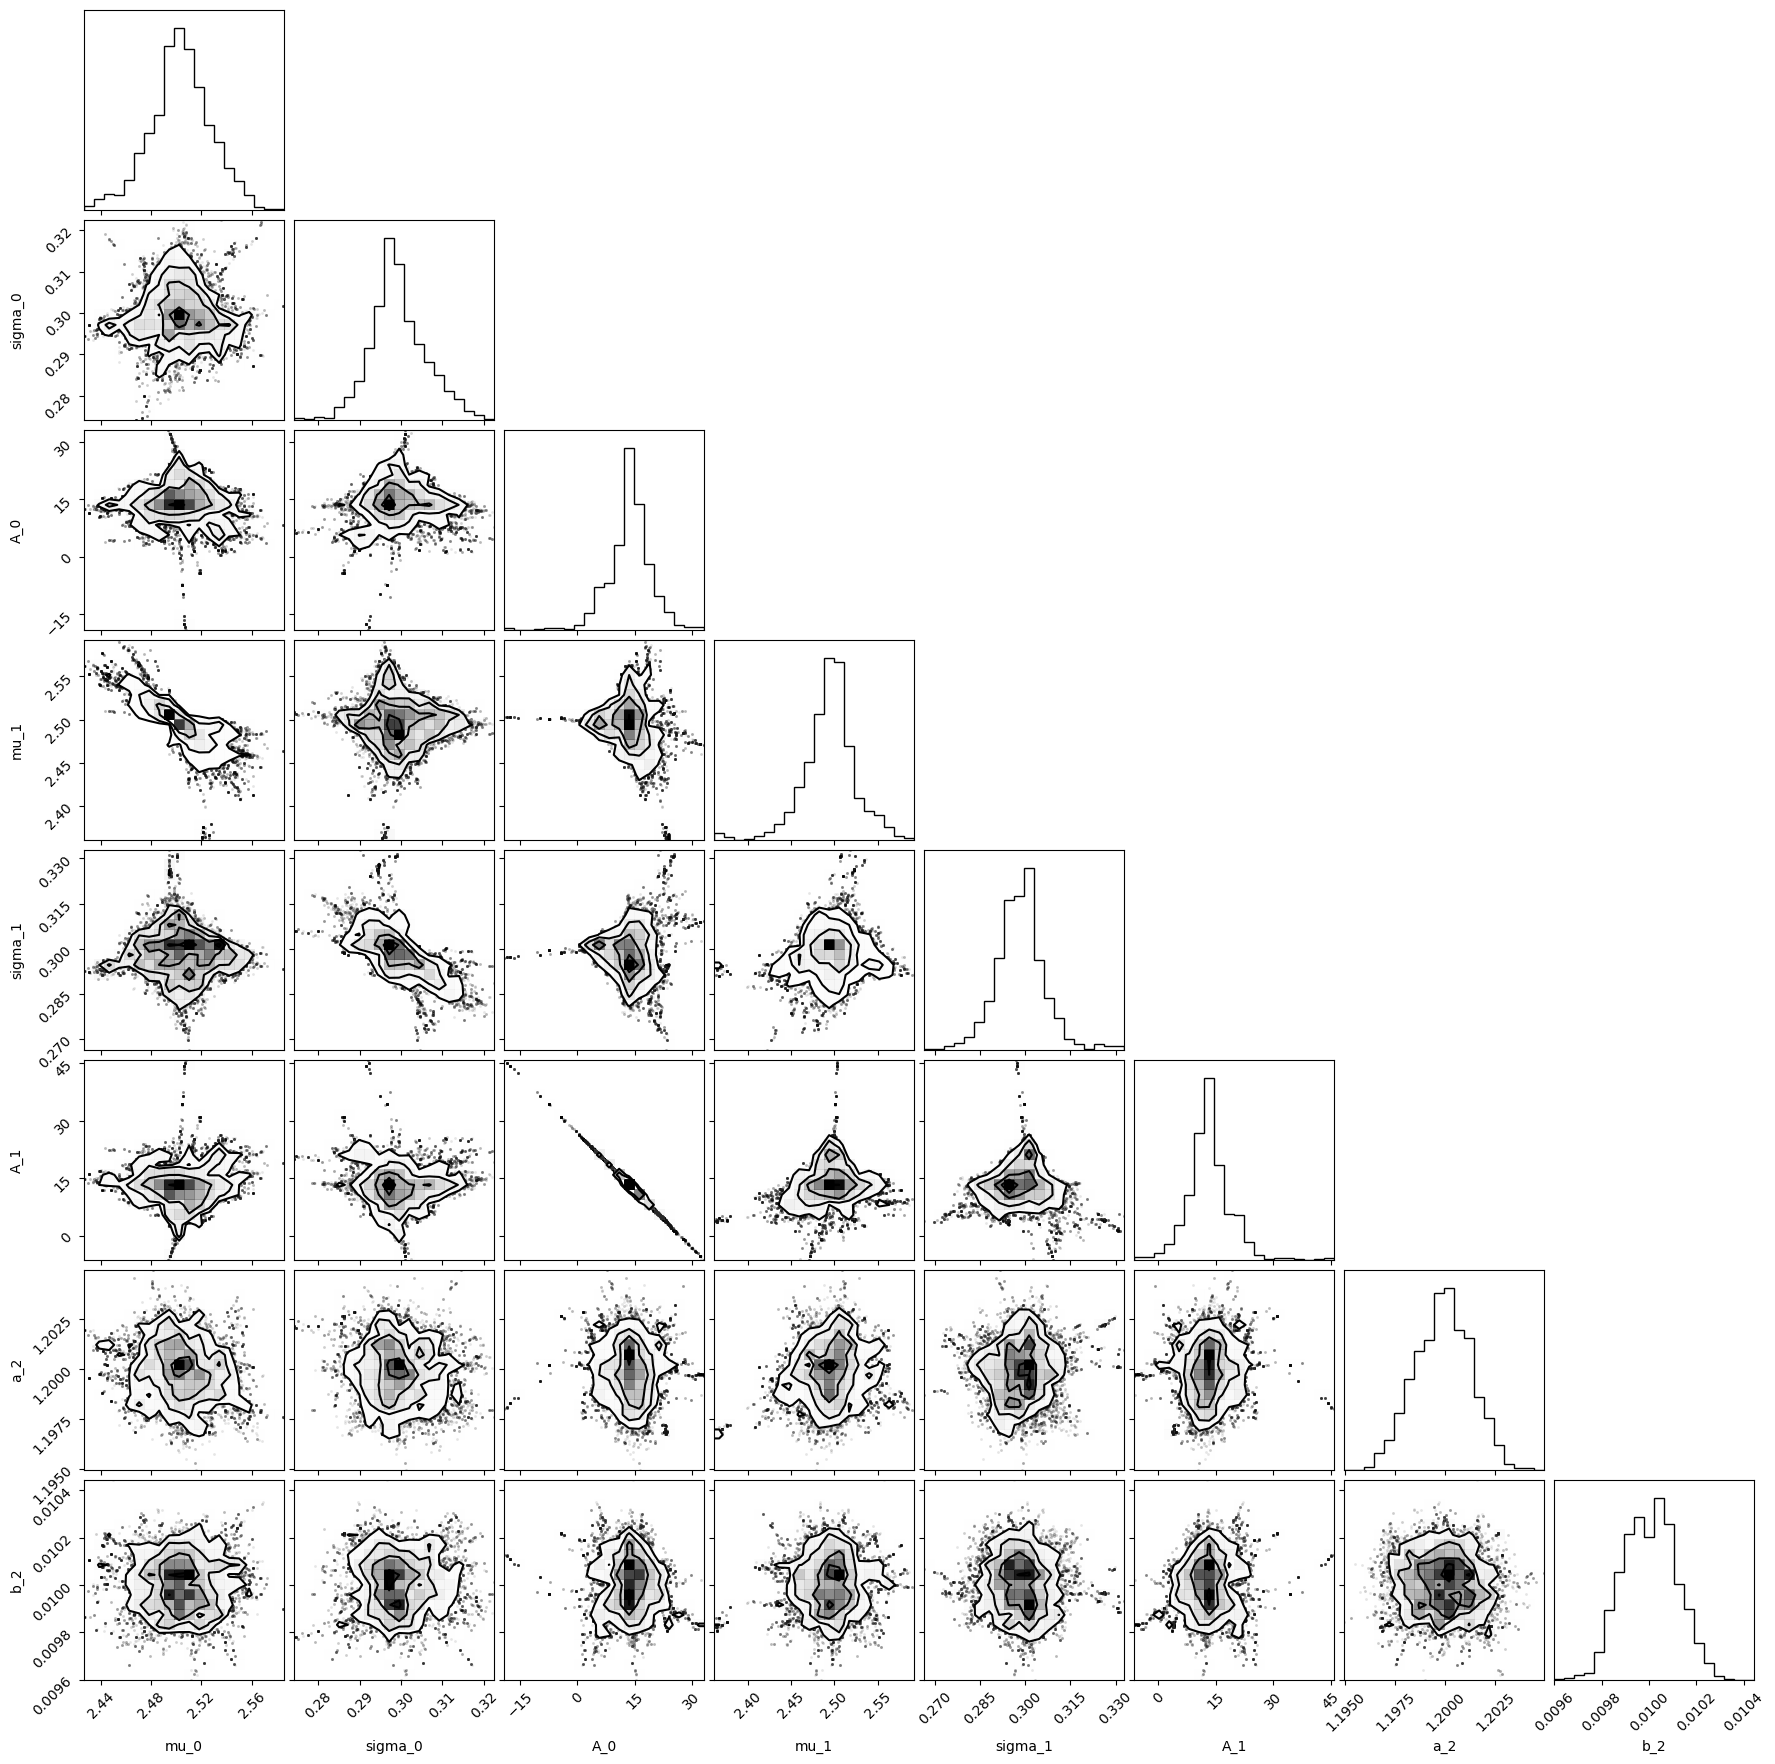

In [57]:
fig =corner.corner(result.flatchain, labels=result.var_names)